# Demographics Prediction Analysis

**Research Question**: How well can gender and age be predicted from functional connectivity, and which FC methods perform best?

**Methodology**: Kernel Ridge Regression (KRR) with Pearson kernel, following He et al. 2020 (doi.org/10.1016/j.neuroimage.2019.116276) methodology.
- **Gender**: KRR regression → threshold at 0.5 for classification accuracy
- **Age**: Continuous regression (MAE, correlation)
- **No confound regression** for demographics (He2019)
- 20-fold outer GroupShuffleSplit (20% test), 20-fold inner GroupKFold
- Inner CV metric: MSE

**Analyses**:
1. **Gender prediction**: Accuracy across all PySPI and skarf methods
2. **Age prediction**: MAE and correlation across all methods
3. **Top performers**: Which FC methods rank highest for each task?
4. **PySPI vs skarf comparison**: Do families differ significantly?

In [1]:
import os
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS
from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
pd.options.display.precision = 4

style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /home/aerkent/skarf-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

result_dir = project_root / "results/hcp_1200_demographics_prediction"

analysis_dir = project_root / "results/hcp_1200_demographics_prediction_analysis"
analysis_dir.mkdir(exist_ok=True)

### Load SPI metadata and skarf function definitions

In [4]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()

spi_id_map = {spi: idx for idx, spi in enumerate(spi_list, start=1)}

spi_table = pd.DataFrame.from_records(
    [
        {
            "spi": spi,
            "category": config["module_name"].split(".")[-1],
            "identifier": spi.split("_")[0],
        }
        for spi, config in spi_config_map.items()
        if spi in spi_list
    ]
)
spi_table["spi"] = pd.Categorical(spi_table["spi"], categories=spi_list, ordered=True)
category_levels = sorted(spi_table["category"].unique())
spi_table["category"] = pd.Categorical(spi_table["category"], categories=category_levels, ordered=True)
identifier_levels = [id_ for id_ in spi_table["identifier"].unique()]
spi_table["identifier"] = pd.Categorical(spi_table["identifier"], categories=identifier_levels, ordered=True)

print(f"Total SPIs: {len(all_spis)}, Selected: {len(spi_list)}")

Total SPIs: 284, Selected: 149


In [5]:
# skarf function categories and display names (from skarf behav prediction notebook)
func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}

func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}

func_category_colors = {
    category: color_cycle[ii] for ii, category in enumerate(func_categories)
}

func_names = {
    "cov_empirical": "cov_empirical",
    "cov_graphicallasso": "cov_graphlasso",
    "prec_empirical": "prec_empirical",
    "prec_graphicallasso": "prec_graphlasso",
    "linear_ols": "lstsq_ols",
    "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso",
    "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso",
    "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls",
    "linear_pca-ridge": "lowrank_pca-ridge",
}

In [6]:
def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0


spi_category_colors = {
    category: color_cycle[ii]
    for ii, category in enumerate(spi_table["category"].cat.categories)
}

### Load demographics prediction results

In [7]:
result_paths = sorted(result_dir.rglob("results.json"))
print(f"Num result files: {len(result_paths)}")

all_results = pd.concat([pd.read_json(path, lines=True) for path in result_paths])
print(f"Total result rows: {len(all_results)}")
all_results.head(3)

Num result files: 344
Total result rows: 6880


,method,func,method_id,parc_size,pool,sparsity,n_splits,n_inner_splits,perm_test,n_subjects,...,mse_test,mae_train,mae_test,corr_train,corr_test,acc_train,acc_test,opt_threshold,opt_acc_train,opt_acc_test
0,pyspi,cov_EmpiricalCovariance,0,200,3,0,20,20,False,NaN,...,9.8232,1.3276,2.5863,0.9282,0.4701,NaN,NaN,NaN,NaN,NaN
1,pyspi,cov_EmpiricalCovariance,0,200,3,0,20,20,False,NaN,...,11.5496,1.3236,2.7982,0.9272,0.4503,NaN,NaN,NaN,NaN,NaN
2,pyspi,cov_EmpiricalCovariance,0,200,3,0,20,20,False,NaN,...,10.6245,1.3423,2.7356,0.9247,0.5314,NaN,NaN,NaN,NaN,NaN


In [8]:

# Exclude degenerate matrices
degenerate_lookup_path = project_root / "resources/matrix_degenerate_lookup.json"
degenerate_lookup = pd.read_json(degenerate_lookup_path, typ="series")
degenerate_keys = set(degenerate_lookup[degenerate_lookup].index)

all_results["_lookup_key"] = all_results["method"] + "__" + all_results["func"]
mask_degenerate = all_results["_lookup_key"].isin(degenerate_keys)
excluded_keys = all_results.loc[mask_degenerate, "_lookup_key"].unique().tolist()
all_results = all_results[~mask_degenerate].drop(columns=["_lookup_key"]).copy()

print(f"Degenerate combos in lookup: {degenerate_keys}")
print(f"Excluded keys present in results: {excluded_keys}")
print(f"Remaining rows: {len(all_results)}")


Degenerate combos in lookup: {'pyspi__bary_euclidean_mean', 'pyspi__lmfit_Lasso'}
Excluded keys present in results: ['pyspi__bary_euclidean_mean', 'pyspi__lmfit_Lasso']
Remaining rows: 6800


In [9]:
# Split into gender and age results
gender_results = all_results.query("task == 'gender'").copy()
age_results = all_results.query("task == 'age'").copy()

print(f"Gender results: {len(gender_results)} rows")
print(f"Age results: {len(age_results)} rows")

Gender results: 3400 rows
Age results: 3400 rows


In [10]:
# Split by method type
gender_pyspi = gender_results.query("method == 'pyspi'").copy()
gender_skarf = gender_results.query("method == 'skarf'").copy()
age_pyspi = age_results.query("method == 'pyspi'").copy()
age_skarf = age_results.query("method == 'skarf'").copy()

print(f"Gender PySPI: {gender_pyspi['func'].nunique()} funcs, {len(gender_pyspi)} rows")
print(f"Gender skarf: {gender_skarf['func'].nunique()} funcs, {len(gender_skarf)} rows")
print(f"Age PySPI: {age_pyspi['func'].nunique()} funcs, {len(age_pyspi)} rows")
print(f"Age skarf: {age_skarf['func'].nunique()} funcs, {len(age_skarf)} rows")

Gender PySPI: 146 funcs, 2920 rows
Gender skarf: 12 funcs, 480 rows
Age PySPI: 146 funcs, 2920 rows
Age skarf: 12 funcs, 480 rows


### Aggregate results

Compute median performance across splits for each method/func.

In [11]:
# PySPI aggregation
pyspi_gender_agg = gender_pyspi.groupby("func").agg(
    n_splits=("split", "count"),
    acc_test_median=("acc_test", "median"),
    corr_test_median=("corr_test", "median"),
).sort_values("acc_test_median", ascending=False)

pyspi_age_agg = age_pyspi.groupby("func").agg(
    n_splits=("split", "count"),
    mae_test_median=("mae_test", "median"),
    corr_test_median=("corr_test", "median"),
).sort_values("corr_test_median", ascending=False)

print("Top 10 PySPI methods for gender prediction (accuracy):")
pyspi_gender_agg.head(10)

Top 10 PySPI methods for gender prediction (accuracy):


,n_splits,acc_test_median,corr_test_median
func,,,
prec_ShrunkCovariance,20,0.9489,0.8524
prec_LedoitWolf,20,0.9325,0.8266
prec_OAS,20,0.9297,0.8255
pdist_canberra,20,0.9168,0.8150
kendalltau,20,0.9157,0.8150
tlmi_gaussian,20,0.9155,0.8138
dcorr,20,0.9150,0.8034
pdist_cityblock,20,0.9146,0.8146
tlmi_kernel_W-0.25,20,0.9142,0.8120


In [12]:
print("Top 10 PySPI methods for age prediction (correlation):")
pyspi_age_agg.head(10)

Top 10 PySPI methods for age prediction (correlation):


,n_splits,mae_test_median,corr_test_median
func,,,
pdist_canberra,20,2.7004,0.4708
ce_kernel_W-0.5,20,2.7218,0.4637
pdist_euclidean,20,2.7138,0.4591
pdist_cityblock,20,2.7282,0.4580
dtw_constraint-sakoe-chiba,20,2.7818,0.4434
pdist_cosine,20,2.7750,0.4416
kendalltau,20,2.7961,0.4363
cov_EmpiricalCovariance,20,2.8039,0.4342
cov_ShrunkCovariance,20,2.8039,0.4342


In [13]:
# skarf aggregation
skarf_gender_agg = gender_skarf.groupby(["func", "lag"]).agg(
    n_splits=("split", "count"),
    acc_test_median=("acc_test", "median"),
    corr_test_median=("corr_test", "median"),
).sort_values("acc_test_median", ascending=False)

skarf_age_agg = age_skarf.groupby(["func", "lag"]).agg(
    n_splits=("split", "count"),
    mae_test_median=("mae_test", "median"),
    corr_test_median=("corr_test", "median"),
).sort_values("corr_test_median", ascending=False)

print("skarf methods for gender prediction (accuracy):")
skarf_gender_agg

skarf methods for gender prediction (accuracy):


n_splits  acc_test_median  corr_test_median
func                lag                                             
linear_ridge        1          20           0.9483            0.8503
linear_pca-ridge    0          20           0.9457            0.8462
linear_ridge        0          20           0.9382            0.8376
linear_pca-ridge    1          20           0.9380            0.8466
linear_pls          0          20           0.9290            0.8330
                    1          20           0.9282            0.8334
linear_enet         1          20           0.9203            0.8091
linear_enet-pos     1          20           0.9171            0.8034
prec_graphicallasso 0          20           0.9152            0.8042
linear_enet-pos     0          20           0.9119            0.8047
linear_enet         0          20           0.9084            0.8087
prec_graphicallasso 1          20           0.9071            0.8003
linear_lasso        0          20           0.9065            0.8013
                    1          20           0.9064            0.7982
linear_lasso-pos    0          20           0.9041            0.7960
cov_empirical       0          20           0.8971            0.7929
linear_lasso-pos    1          20           0.8964            0.7886
cov_empirical       1          20           0.8872            0.7750
cov_graphicallasso  0          20           0.8680            0.7544
                    1          20           0.8583            0.7435
prec_empirical      0          20           0.6695            0.3990
linear_ols          0          20           0.6695            0.3990
prec_empirical      1          20           0.6695            0.4054
linear_ols          1          20           0.4583            0.0347

In [14]:
print("skarf methods for age prediction (correlation):")
skarf_age_agg

skarf methods for age prediction (correlation):


,,n_splits,mae_test_median,corr_test_median
func,lag,,,
linear_pca-ridge,0,20,2.8070,0.4383
linear_ridge,1,20,2.8326,0.4370
linear_pca-ridge,1,20,2.7644,0.4277
linear_enet-pos,1,20,2.8327,0.4173
linear_enet,0,20,2.8156,0.4107
linear_enet-pos,0,20,2.7974,0.4089
linear_lasso,0,20,2.8172,0.3944
linear_lasso-pos,0,20,2.8721,0.3927
linear_enet,1,20,2.8680,0.3915


### Empirical covariance baseline

Use `cov_EmpiricalCovariance` (PySPI) as the baseline reference, same as behavioral prediction.

In [15]:
baseline_func = "cov_EmpiricalCovariance"

gender_baseline = gender_pyspi.query(f"func == '{baseline_func}'")
age_baseline = age_pyspi.query(f"func == '{baseline_func}'")

print(f"Gender baseline — median accuracy: {gender_baseline['acc_test'].median():.4f}")
print(f"Age baseline — median correlation: {age_baseline['corr_test'].median():.4f}, median MAE: {age_baseline['mae_test'].median():.4f}")

Gender baseline — median accuracy: 0.9107
Age baseline — median correlation: 0.4342, median MAE: 2.8039


## Gender Prediction

### PySPI methods — gender accuracy

In [16]:
def plot_pyspi_boxplots(results_df, metric_col, metric_label, baseline_df, task_name, topk=2):
    """Plot boxplots for all PySPI methods grouped by SPI category."""
    baseline_score = baseline_df[metric_col].median()
    baseline_values = baseline_df[metric_col].values

    # SPI families in poster Figure 2 order
    cat_identifier_list = list(
        {(cat, ident): None for cat, ident in zip(spi_table["category"], spi_table["identifier"])}
    )

    # Aggregate median scores per SPI
    results_agg = results_df.groupby("func")[metric_col].median()

    data = []
    labels = []
    colors = []
    num_comparisons = results_df["func"].nunique()

    for category, identifier in cat_identifier_list:
        family_spis = spi_table.query(f"category == '{category}' and identifier == '{identifier}'")["spi"].tolist()
        family_spis = [spi for spi in family_spis if spi in results_agg.index]

        if not family_spis:
            continue

        ascending = "mae" in metric_col.lower()
        topk_spis = results_agg.loc[family_spis].sort_values(ascending=ascending).head(topk).index.tolist()
        color = spi_category_colors[category]

        for spi in topk_spis:
            values = results_df.query(f"func == '{spi}'")[metric_col].values
            if len(values) == 0:
                continue
            score = np.median(values)

            _, baseline_pval = stats.mannwhitneyu(values, baseline_values)

            label = f"({spi_id_map[spi]:03d}) {spi[:18]}"

            if get_significance(baseline_pval * num_comparisons):
                label = f"{'(<)' if score < baseline_score else '(>)'} {label}"
            else:
                label = f"(~) {label}"

            data.append(values)
            labels.append(label)
            colors.append(color)

    f, ax = plt.subplots(1, 1, figsize=(2 * PLOTW, 0.75 * PLOTW), layout="constrained")

    pos = np.arange(len(data))
    bplot = plt.boxplot(data, positions=pos, patch_artist=True, medianprops={"color": "k"})
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)

    plt.axhline(baseline_score, color="r", alpha=0.5)
    plt.ylabel(metric_label, fontsize="medium")
    plt.xticks(pos, labels, rotation=90, fontsize="xx-small")

    ymin, ymax = plt.ylim()
    plt.ylim(ymin, ymin + 1.1 * (ymax - ymin))

    for category in category_levels:
        if category in spi_category_colors:
            plt.bar([0], [0], width=0, color=spi_category_colors[category], edgecolor="none", label=category)
    plt.legend(loc="upper center", ncol=7, fontsize="x-small")

    plt.title(f"{task_name} — PySPI", fontsize="medium")
    return f

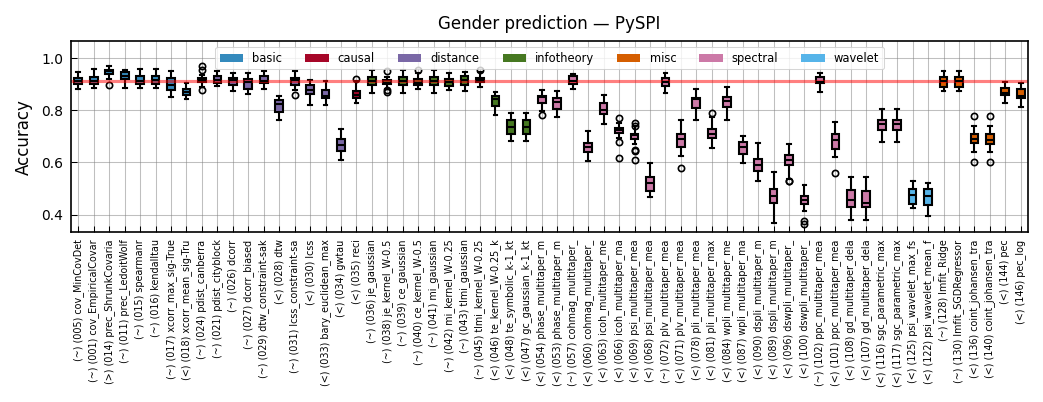

In [17]:
f = plot_pyspi_boxplots(
    gender_pyspi, "acc_test", "Accuracy", gender_baseline, "Gender prediction"
)
f.savefig(analysis_dir / f"gender_pyspi_accuracy.{FORMAT}", bbox_inches="tight")

### skarf methods — gender accuracy

In [18]:
def plot_skarf_boxplots(results_df, metric_col, metric_label, baseline_df, task_name):
    """Plot boxplots for skarf methods with lag=0 and lag=1 side by side."""
    baseline_score = baseline_df[metric_col].median()
    baseline_values = baseline_df[metric_col].values

    lags = sorted(results_df["lag"].unique())
    lag_styles = {0: {"alpha": 0.85, "hatch": ""}, 1: {"alpha": 0.45, "hatch": "//"}}

    # Get available funcs in canonical order
    available_funcs = [f for f in AVAILABLE_SKARF_FUNCS if f in results_df["func"].values]
    num_comparisons = len(available_funcs)
    positions = np.arange(len(available_funcs))

    labels = []
    category_colors = []

    for func in available_funcs:
        # Significance at lag=0
        lag0_values = results_df.query(f"func == '{func}' and lag == 0")[metric_col].values
        if len(lag0_values) > 0:
            _, baseline_pval = stats.mannwhitneyu(lag0_values, baseline_values)
            score = np.median(lag0_values)
        else:
            baseline_pval = 1.0
            score = 0.0

        name = func_names[func]
        _, label = name.split("_", maxsplit=1)

        if get_significance(baseline_pval * num_comparisons):
            label = f"{'(<)' if score < baseline_score else '(>)'} {label}"
        else:
            label = f"(~) {label}"

        labels.append(label)
        category_colors.append(func_category_colors[func_category_map[func]])

    fig, ax = plt.subplots(1, 1, figsize=(1.1 * PLOTW, 0.8 * PLOTW), layout="constrained")

    for offset, lag in zip(np.linspace(-0.15, 0.15, len(lags)), lags):
        lag_data = [
            results_df.query(f"func == '{func}' and lag == {lag}")[metric_col].values
            for func in available_funcs
        ]
        # Skip lags with no data
        if all(len(d) == 0 for d in lag_data):
            continue

        bplot = ax.boxplot(
            lag_data, positions=positions + offset, widths=0.25,
            patch_artist=True, medianprops={"color": "k"},
        )
        for patch, color in zip(bplot["boxes"], category_colors):
            patch.set_facecolor(color)
            patch.set_alpha(lag_styles[lag]["alpha"])
            patch.set_hatch(lag_styles[lag]["hatch"])
            patch.set_edgecolor(color)

    ax.axhline(baseline_score, color="r", alpha=0.6, linestyle="--")
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, fontsize="x-small")

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymin + 1.1 * (ymax - ymin))

    # Lag legend
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"],
                       hatch=lag_styles[lag]["hatch"], label=f"Lag {lag}")
        for lag in lags
    ]
    lag_legend = ax.legend(handles=lag_handles, loc="upper left", bbox_to_anchor=(1.0, 0.9), fontsize="small")
    ax.add_artist(lag_legend)

    # Category legend
    category_handles = [
        mpatches.Patch(facecolor=color, label=category)
        for category, color in func_category_colors.items()
    ]
    ax.legend(handles=category_handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small")

    ax.set_title(f"{task_name} — skarf", fontsize="medium")
    return fig

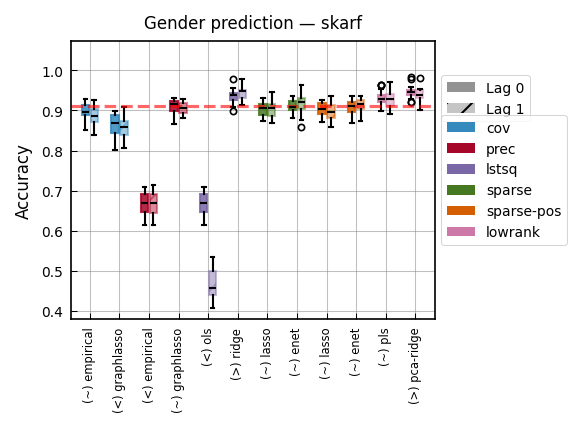

In [19]:
f = plot_skarf_boxplots(
    gender_skarf, "acc_test", "Accuracy", gender_baseline, "Gender prediction"
)
f.savefig(analysis_dir / f"gender_skarf_accuracy.{FORMAT}", bbox_inches="tight")

## Age Prediction

### PySPI methods — age correlation

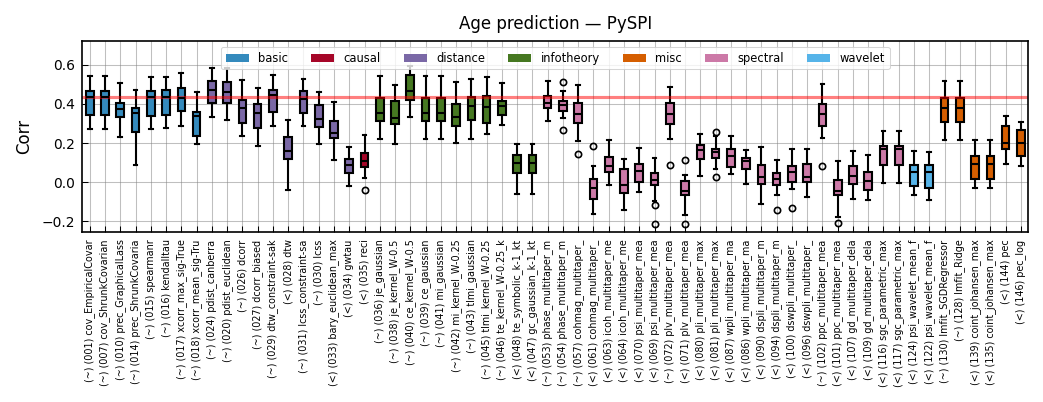

In [20]:
f = plot_pyspi_boxplots(
    age_pyspi, "corr_test", "Corr", age_baseline, "Age prediction"
)
f.savefig(analysis_dir / f"age_pyspi_corr.{FORMAT}", bbox_inches="tight")

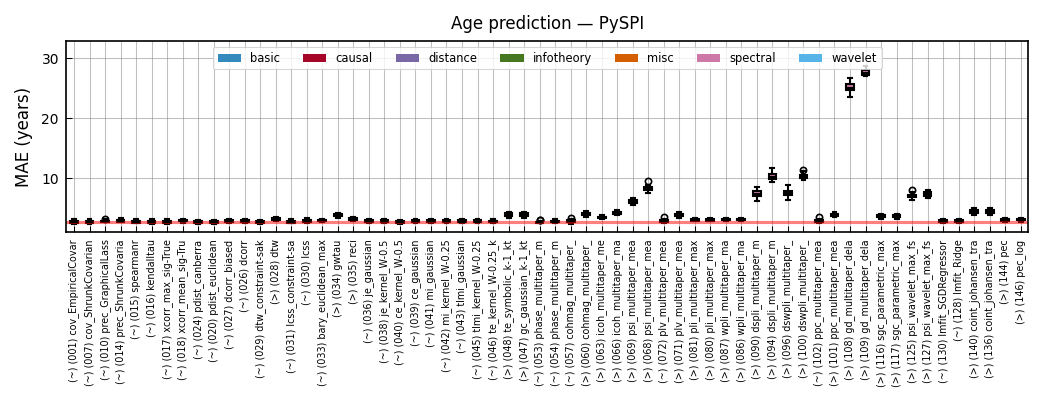

In [21]:
f = plot_pyspi_boxplots(
    age_pyspi, "mae_test", "MAE (years)", age_baseline, "Age prediction"
)
f.savefig(analysis_dir / f"age_pyspi_mae.{FORMAT}", bbox_inches="tight")

### skarf methods — age correlation and MAE

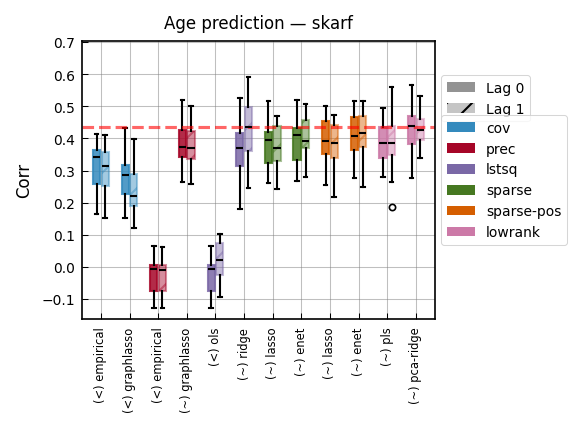

In [22]:
f = plot_skarf_boxplots(
    age_skarf, "corr_test", "Corr", age_baseline, "Age prediction"
)
f.savefig(analysis_dir / f"age_skarf_corr.{FORMAT}", bbox_inches="tight")

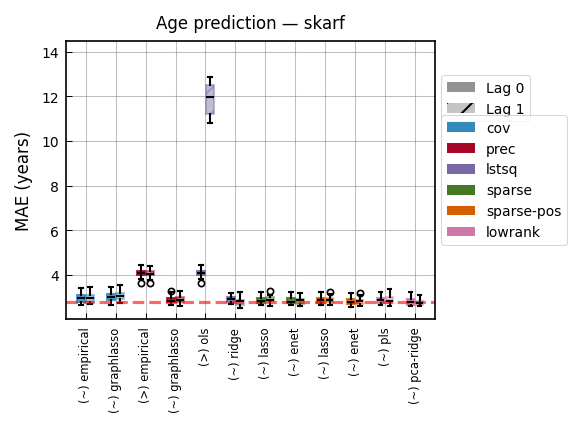

In [23]:
f = plot_skarf_boxplots(
    age_skarf, "mae_test", "MAE (years)", age_baseline, "Age prediction"
)
f.savefig(analysis_dir / f"age_skarf_mae.{FORMAT}", bbox_inches="tight")

## Summary tables

### Top 10 overall (both PySPI and skarf)

In [24]:
# Gender: top 10 by accuracy across all methods
gender_all_agg = all_results.query("task == 'gender'").groupby(["method", "func", "lag"]).agg(
    n_splits=("split", "count"),
    acc_median=("acc_test", "median"),
    acc_mean=("acc_test", "mean"),
    acc_std=("acc_test", "std"),
    corr_median=("corr_test", "median"),
).sort_values("acc_median", ascending=False)

print("Top 10 methods for GENDER prediction:")
gender_all_agg.head(10)

Top 10 methods for GENDER prediction:


n_splits  acc_median  acc_mean  acc_std  \
method func                  lag                                            
pyspi  prec_ShrunkCovariance 0          20      0.9489    0.9450   0.0176   
skarf  linear_ridge          1          20      0.9483    0.9446   0.0164   
       linear_pca-ridge      0          20      0.9457    0.9466   0.0155   
       linear_ridge          0          20      0.9382    0.9350   0.0184   
       linear_pca-ridge      1          20      0.9380    0.9372   0.0194   
pyspi  prec_LedoitWolf       0          20      0.9325    0.9290   0.0204   
       prec_OAS              0          20      0.9297    0.9291   0.0192   
skarf  linear_pls            0          20      0.9290    0.9326   0.0177   
                             1          20      0.9282    0.9264   0.0204   
       linear_enet           1          20      0.9203    0.9166   0.0261   

                                  corr_median  
method func                  lag               
pyspi  prec_ShrunkCovariance 0         0.8524  
skarf  linear_ridge          1         0.8503  
       linear_pca-ridge      0         0.8462  
       linear_ridge          0         0.8376  
       linear_pca-ridge      1         0.8466  
pyspi  prec_LedoitWolf       0         0.8266  
       prec_OAS              0         0.8255  
skarf  linear_pls            0         0.8330  
                             1         0.8334  
       linear_enet           1         0.8091

In [25]:
# Age: top 10 by correlation across all methods
age_all_agg = all_results.query("task == 'age'").groupby(["method", "func", "lag"]).agg(
    n_splits=("split", "count"),
    corr_median=("corr_test", "median"),
    corr_mean=("corr_test", "mean"),
    corr_std=("corr_test", "std"),
    mae_median=("mae_test", "median"),
).sort_values("corr_median", ascending=False)

print("Top 10 methods for AGE prediction:")
age_all_agg.head(10)

Top 10 methods for AGE prediction:


n_splits  corr_median  corr_mean  \
method func                       lag                                     
pyspi  pdist_canberra             0          20       0.4708     0.4633   
       ce_kernel_W-0.5            0          20       0.4637     0.4651   
       pdist_euclidean            0          20       0.4591     0.4561   
       pdist_cityblock            0          20       0.4580     0.4499   
       dtw_constraint-sakoe-chiba 0          20       0.4434     0.4244   
       pdist_cosine               0          20       0.4416     0.4273   
skarf  linear_pca-ridge           0          20       0.4383     0.4288   
       linear_ridge               1          20       0.4370     0.4315   
pyspi  kendalltau                 0          20       0.4363     0.4139   
       cov_EmpiricalCovariance    0          20       0.4342     0.4121   

                                       corr_std  mae_median  
method func                       lag                        
pyspi  pdist_canberra             0      0.0751      2.7004  
       ce_kernel_W-0.5            0      0.0756      2.7218  
       pdist_euclidean            0      0.0774      2.7138  
       pdist_cityblock            0      0.0760      2.7282  
       dtw_constraint-sakoe-chiba 0      0.0794      2.7818  
       pdist_cosine               0      0.0814      2.7750  
skarf  linear_pca-ridge           0      0.0752      2.8070  
       linear_ridge               1      0.0925      2.8326  
pyspi  kendalltau                 0      0.0819      2.7961  
       cov_EmpiricalCovariance    0      0.0826      2.8039

### PySPI vs skarf family comparison

Compare distribution of median scores between PySPI and skarf method families.

In [26]:
def compare_families(results_df, metric_col, task_name):
    """Compare PySPI vs skarf (lag=0) median scores with Mann-Whitney U test."""
    # Median per method/func
    pyspi_medians = (
        results_df.query("method == 'pyspi'")
        .groupby("func")[metric_col].median()
        .values
    )
    skarf_medians = (
        results_df.query("method == 'skarf' and lag == 0")
        .groupby("func")[metric_col].median()
        .values
    )

    stat, pval = stats.mannwhitneyu(pyspi_medians, skarf_medians)

    print(f"{task_name} — {metric_col}:")
    print(f"  PySPI: n={len(pyspi_medians)}, median={np.median(pyspi_medians):.4f}")
    print(f"  skarf: n={len(skarf_medians)}, median={np.median(skarf_medians):.4f}")
    print(f"  Mann-Whitney U stat={stat:.1f}, p={pval:.4e}")
    print()


compare_families(all_results.query("task == 'gender'"), "acc_test", "Gender")
compare_families(all_results.query("task == 'age'"), "corr_test", "Age (corr)")
compare_families(all_results.query("task == 'age'"), "mae_test", "Age (MAE)")

Gender — acc_test:
  PySPI: n=146, median=0.6643
  skarf: n=12, median=0.9074
  Mann-Whitney U stat=342.0, p=4.6186e-04

Age (corr) — corr_test:
  PySPI: n=146, median=0.0834
  skarf: n=12, median=0.3795
  Mann-Whitney U stat=435.0, p=3.8382e-03

Age (MAE) — mae_test:
  PySPI: n=146, median=4.0769
  skarf: n=12, median=2.8794
  Mann-Whitney U stat=1362.0, p=1.4400e-03



### Combined distribution comparison

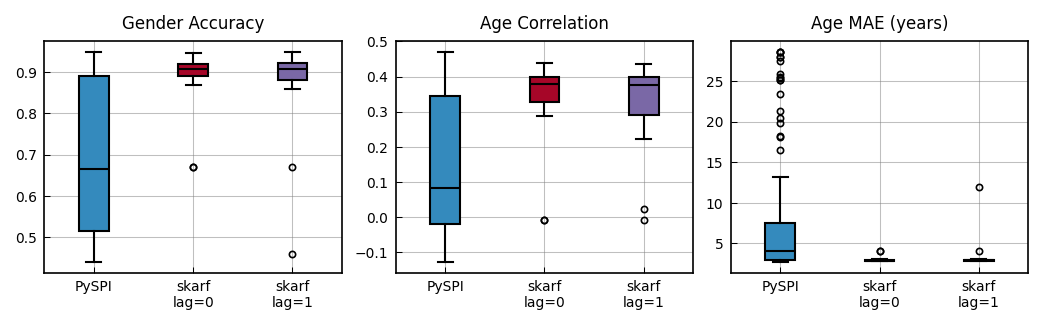

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(2 * PLOTW, 0.6 * PLOTW), layout="constrained")

configs = [
    ("task == 'gender'", "acc_test", "Gender Accuracy"),
    ("task == 'age'", "corr_test", "Age Correlation"),
    ("task == 'age'", "mae_test", "Age MAE (years)"),
]

for ax, (query, metric_col, title) in zip(axes, configs):
    sub = all_results.query(query)

    pyspi_medians = sub.query("method == 'pyspi'").groupby("func")[metric_col].median().values
    skarf_lag0_medians = sub.query("method == 'skarf' and lag == 0").groupby("func")[metric_col].median().values
    skarf_lag1_medians = sub.query("method == 'skarf' and lag == 1").groupby("func")[metric_col].median().values

    data = [pyspi_medians, skarf_lag0_medians, skarf_lag1_medians]
    bp = ax.boxplot(data, patch_artist=True, medianprops={"color": "k"})
    for patch, color in zip(bp["boxes"], [color_cycle[0], color_cycle[1], color_cycle[2]]):
        patch.set_facecolor(color)

    ax.set_xticklabels(["PySPI", "skarf\nlag=0", "skarf\nlag=1"], fontsize="small")
    ax.set_title(title, fontsize="medium")

fig.savefig(analysis_dir / f"family_comparison_boxplots.{FORMAT}", bbox_inches="tight")
plt.show()

## Poster-style figures

In [28]:
TOPK_PER_CATEGORY = 2
LAG_ORDER = [0, 1]
lag_styles = {0: {"alpha": 0.85, "hatch": ""}, 1: {"alpha": 0.45, "hatch": "//"}}
NULL_BAND_COLOR = "#6c757d"
BASELINE_BAND_COLOR = "#d95f02"
NULL_BAND_ALPHA = 0.18
BASELINE_BAND_ALPHA = 0.22


def add_iqr_band(ax, q25: float, q75: float, color: str, alpha: float = 0.2, label: str | None = None, zorder: float = 0.1):
    span = ax.axhspan(q25, q75, color=color, alpha=alpha, zorder=zorder, linewidth=0)
    if label:
        span.set_label(label)
    return span


def format_label(base_label: str, values: np.ndarray, null_p: float, baseline_p: float, bonferroni_factor: int, baseline_score: float) -> str:
    null_sig = get_significance(null_p * bonferroni_factor)
    if not null_sig:
        prefix = "(·)"
    else:
        baseline_sig = get_significance(baseline_p * bonferroni_factor)
        if baseline_sig:
            prefix = "(<)" if np.median(values) < baseline_score else "(>)"
        else:
            prefix = "(~)"
    return f"{prefix} {base_label}"


# Load permutation null results
perm_dir = project_root / "results/hcp_1200_demographics_prediction_perm_test"
perm_paths = sorted(perm_dir.rglob("results.json"))
if not perm_paths:
    raise FileNotFoundError(f"No perm test results found under {perm_dir}")
perm_results = pd.concat([pd.read_json(p, lines=True) for p in perm_paths])
gender_perm = perm_results.query("task == 'gender'")
age_perm = perm_results.query("task == 'age'")

print(f"Loaded {len(gender_perm)} gender perm splits, {len(age_perm)} age perm splits")

Loaded 200 gender perm splits, 200 age perm splits


In [29]:
METRIC_CONFIGS = {
    "gender_acc": {"metric_key": "acc_test", "task": "gender", "label": "Accuracy", "suffix": "gender_acc"},
    "age_corr": {"metric_key": "corr_test", "task": "age", "label": "Pearson correlation ($r$)", "suffix": "age_corr"},
    "age_mae": {"metric_key": "mae_test", "task": "age", "label": "MAE (years)", "suffix": "age_mae"},
    "age_mae_zoom": {"metric_key": "mae_test", "task": "age", "label": "MAE (years) (ylim 2 to 5)", "suffix": "age_mae_zoom"},
}

# Filter PySPI results to selected SPIs only and add SPI metadata
pyspi_gender_with_meta = spi_table[["spi", "category", "identifier"]].merge(
    gender_pyspi.rename(columns={"func": "spi"}), on="spi", how="inner"
)
pyspi_age_with_meta = spi_table[["spi", "category", "identifier"]].merge(
    age_pyspi.rename(columns={"func": "spi"}), on="spi", how="inner"
)

metric_contexts = {}

for config_key, meta in METRIC_CONFIGS.items():
    metric_key = meta["metric_key"]
    task = meta["task"]

    # Select task-specific data
    if task == "gender":
        pyspi_base = pyspi_gender_with_meta
        skarf_base = gender_skarf
        baseline_reference = gender_baseline[metric_key].dropna().values
        perm_null_values = gender_perm[metric_key].dropna().values
    else:
        pyspi_base = pyspi_age_with_meta
        skarf_base = age_skarf
        baseline_reference = age_baseline[metric_key].dropna().values
        perm_null_values = age_perm[metric_key].dropna().values

    baseline_score = float(np.median(baseline_reference))
    perm_q25, perm_q75 = np.nanpercentile(perm_null_values, [25, 75])
    baseline_q25, baseline_q75 = np.nanpercentile(baseline_reference, [25, 75])

    # PySPI: group by category/identifier/spi, pick top-k per family
    pyspi_values = (
        pyspi_base.groupby(["category", "identifier", "spi"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    pyspi_values["values"] = pyspi_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    pyspi_values["median"] = pyspi_values["values"].apply(lambda arr: np.median(arr) if arr.size else np.nan)
    pyspi_values = pyspi_values.sort_values(
        ["category", "identifier", "median"], ascending=[True, True, False]
    )

    pyspi_panel_rows = []
    for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):
        head_df = df_cat.head(TOPK_PER_CATEGORY)
        for _, row in head_df.iterrows():
            values = row["values"]
            if values.size == 0:
                continue
            null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
            baseline_pval = stats.mannwhitneyu(values, baseline_reference).pvalue
            spi = row["spi"]
            base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
            pyspi_panel_rows.append({
                "category": category,
                "identifier": identifier,
                "spi": spi,
                "values": values,
                "median": np.median(values),
                "null_pval": null_pval,
                "baseline_pval": baseline_pval,
                "base_label": base_label,
            })

    pyspi_panel_df = pd.DataFrame(pyspi_panel_rows)
    if not pyspi_panel_df.empty:
        pyspi_panel_df["color"] = pyspi_panel_df["category"].map(spi_category_colors)
    pyspi_tests = max(len(pyspi_panel_df), 1)
    if not pyspi_panel_df.empty:
        pyspi_panel_df["plot_label"] = pyspi_panel_df.apply(
            lambda row: format_label(
                row["base_label"], row["values"], row["null_pval"],
                row["baseline_pval"], pyspi_tests, baseline_score,
            ), axis=1,
        )
    else:
        pyspi_panel_df["plot_label"] = pd.Series(dtype=str)

    # skarf: group by func/lag
    skarf_values = (
        skarf_base.groupby(["func", "lag"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    skarf_values["values"] = skarf_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    skarf_values["median"] = skarf_values["values"].apply(lambda arr: np.median(arr) if arr.size else np.nan)

    skarf_panel_rows = []
    for _, row in skarf_values.iterrows():
        values = row["values"]
        if values.size == 0:
            continue
        func = row["func"]
        lag = int(row["lag"])
        category = func_category_map[func]
        color = func_category_colors[category]
        base_label = func_names.get(func, func)
        null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
        baseline_pval = stats.mannwhitneyu(values, baseline_reference).pvalue
        skarf_panel_rows.append({
            "func": func, "lag": lag, "category": category,
            "values": values, "median": np.median(values),
            "null_pval": null_pval, "baseline_pval": baseline_pval,
            "base_label": base_label, "color": color,
        })

    skarf_panel_df = pd.DataFrame(skarf_panel_rows)
    skarf_tests = max(len(skarf_panel_df), 1)
    if not skarf_panel_df.empty:
        skarf_panel_df["plot_label"] = skarf_panel_df.apply(
            lambda row: format_label(
                row["base_label"], row["values"], row["null_pval"],
                row["baseline_pval"], skarf_tests, baseline_score,
            ), axis=1,
        )
    else:
        skarf_panel_df["plot_label"] = pd.Series(dtype=str)

    skarf_label_map = {}
    for _, row in skarf_panel_df.iterrows():
        func = row["func"]
        lag = int(row["lag"])
        skarf_label_map[(func, lag)] = f"{row['plot_label']}_lag-{lag}".strip()

    skarf_funcs_present = [
        func for func in AVAILABLE_SKARF_FUNCS if func in skarf_panel_df["func"].unique()
    ]

    metric_contexts[config_key] = {
        "metric_key": metric_key,
        "metric_label": meta["label"],
        "suffix": meta["suffix"],
        "perm_null_values": perm_null_values,
        "baseline_reference": baseline_reference,
        "baseline_score": baseline_score,
        "perm_q25": perm_q25,
        "perm_q75": perm_q75,
        "baseline_q25": baseline_q25,
        "baseline_q75": baseline_q75,
        "pyspi_panel_df": pyspi_panel_df,
        "skarf_panel_df": skarf_panel_df,
        "skarf_label_map": skarf_label_map,
        "skarf_func_order": skarf_funcs_present,
    }

    print(
        f"Prepared context for {config_key} "
        f"(median baseline {baseline_score:.3f}, "
        f"PySPI entries {len(pyspi_panel_df)}, skarf entries {len(skarf_panel_df)})"
    )

Prepared context for gender_acc (median baseline 0.911, PySPI entries 62, skarf entries 24)
Prepared context for age_corr (median baseline 0.434, PySPI entries 62, skarf entries 24)
Prepared context for age_mae (median baseline 2.804, PySPI entries 62, skarf entries 24)
Prepared context for age_mae_zoom (median baseline 2.804, PySPI entries 62, skarf entries 24)


/tmp/ipykernel_52628/2894365271.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):
/tmp/ipykernel_52628/2894365271.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):
/tmp/ipykernel_52628/2894365271.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

Saved poster figure for gender_acc to /home/aerkent/skarf-experiments/results/hcp_1200_demographics_prediction_analysis/poster_figures/demographics_pyspi_skarf_gender_acc.png/.pdf


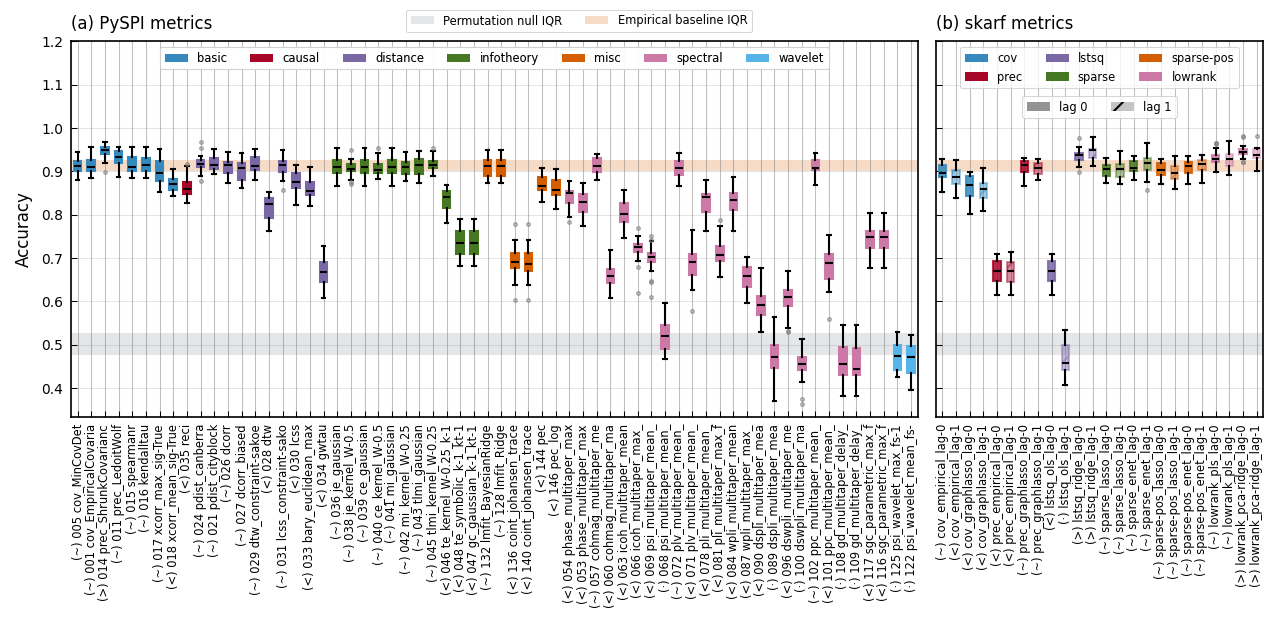

Saved poster figure for age_corr to /home/aerkent/skarf-experiments/results/hcp_1200_demographics_prediction_analysis/poster_figures/demographics_pyspi_skarf_age_corr.png/.pdf


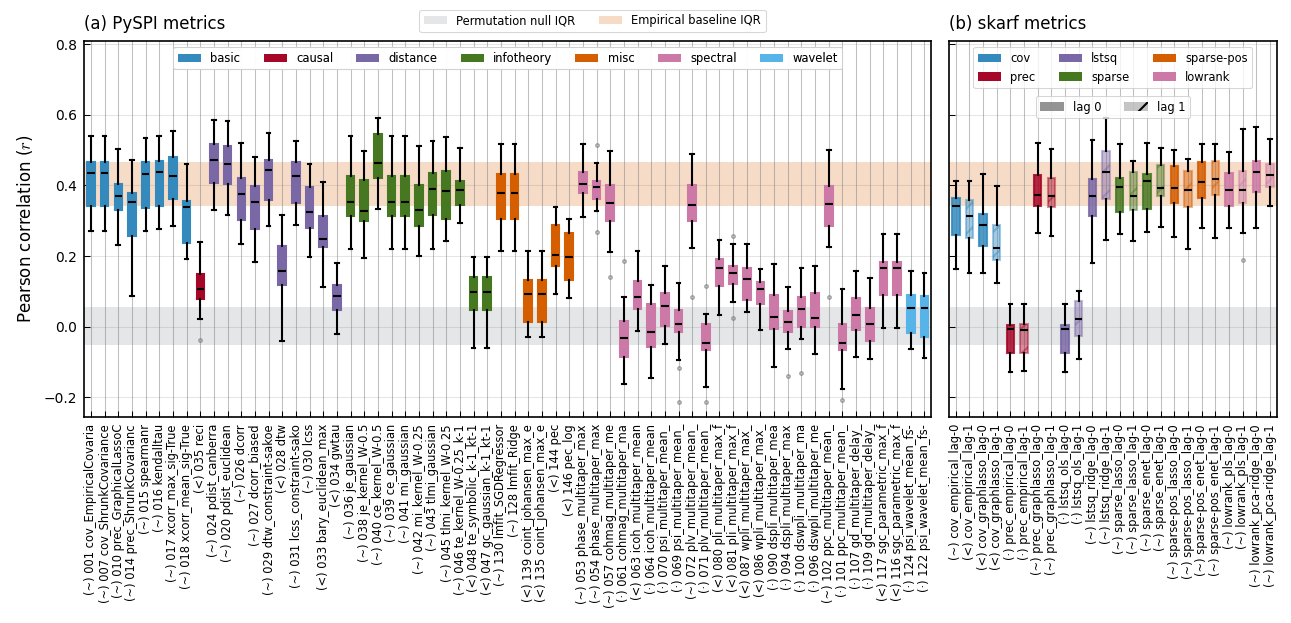

Saved poster figure for age_mae to /home/aerkent/skarf-experiments/results/hcp_1200_demographics_prediction_analysis/poster_figures/demographics_pyspi_skarf_age_mae.png/.pdf


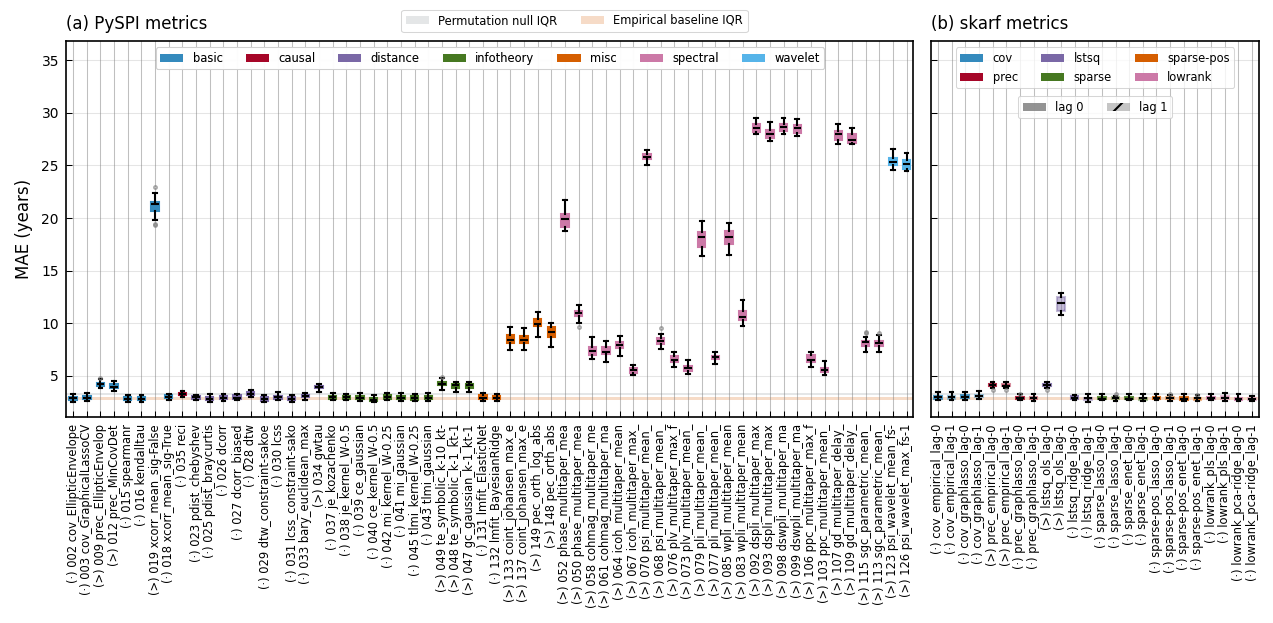

Saved poster figure for age_mae_zoom to /home/aerkent/skarf-experiments/results/hcp_1200_demographics_prediction_analysis/poster_figures/demographics_pyspi_skarf_age_mae_zoom.png/.pdf


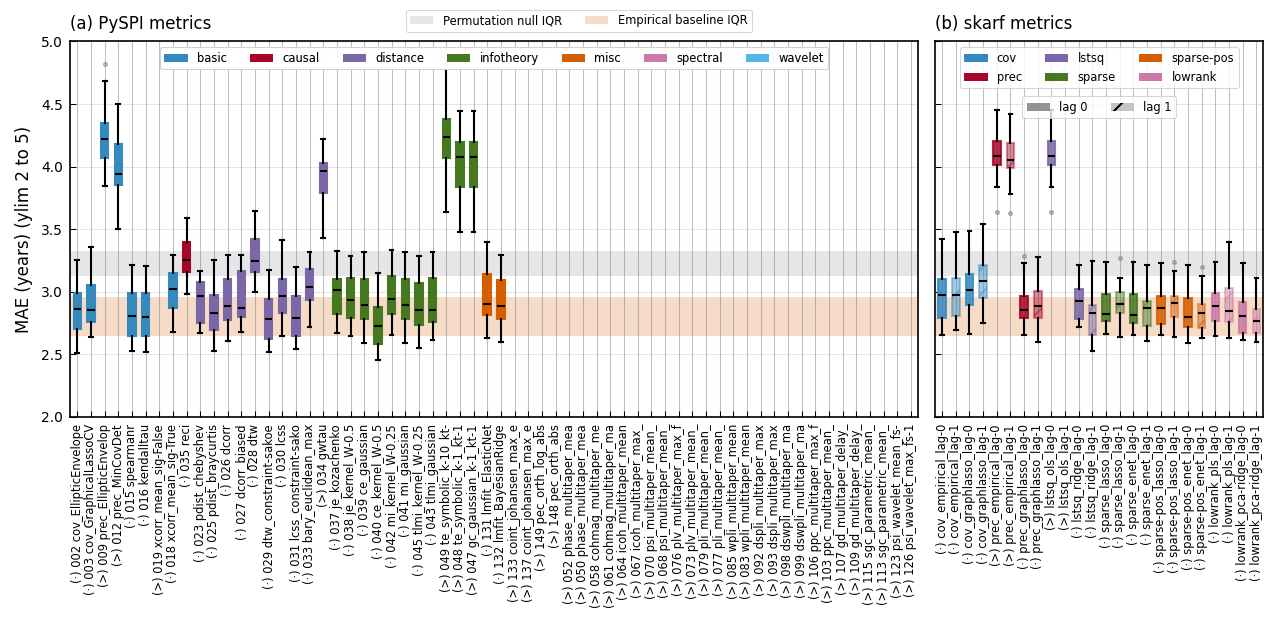

In [30]:
PLOT_DIR = analysis_dir / "poster_figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTLIER_PROPS = dict(
    marker="o",
    markerfacecolor="none",
    markeredgecolor="gray",
    markersize=1.5,
    alpha=0.7,
    linestyle="none",
)

for config_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[config_key]
    pyspi_panel_df = ctx["pyspi_panel_df"]
    skarf_panel_df = ctx["skarf_panel_df"]
    skarf_label_map = ctx["skarf_label_map"]
    skarf_func_order = ctx["skarf_func_order"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            baseline_q25,
            baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Empirical baseline IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ymin, ymax = ax.get_ylim()
        upper = ymin + 1.2 * (ymax - ymin)
        if config_key == "gender_acc":
            upper = max(upper, 1.2)
        ax.set_ylim(ymin, upper)
    pyspi_handles = [
        mpatches.Patch(facecolor=spi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_panel_df["category"].unique()
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")
    
    if config_key == "age_mae_zoom":
        for axis in axes:
            axis.set_ylim(2, 5)

    plt.subplots_adjust(wspace=0.03)

    figure_base = PLOT_DIR / f"demographics_pyspi_skarf_{suffix}"
    fig.savefig(f"{figure_base}.png", dpi=300)
    fig.savefig(f"{figure_base}.pdf")
    print(f"Saved poster figure for {config_key} to {figure_base}.png/.pdf")

    plt.show()

**Demographics Prediction Figures.** Predictive accuracy of connectivity representations for HCP demographics rendered for four metric configurations. In all panels, (a) shows PySPI metrics grouped by SPI family with only the top-$k$ performers per family displayed; colors denote module classes and semi-transparent bands indicate the permutation-null and empirical covariance interquartile ranges. (b) shows skarf VAR estimators with lag-0 (solid) and lag-1 (hatched) distributions for each function category, sharing the same null/baseline reference bands. The baseline is `cov_EmpiricalCovariance` (PySPI). Notation: (·) indicates performance not exceeding the permutation-derived null (Bonferroni-corrected), (~) denotes no detectable difference from the baseline, and (<)/(>) flag significantly lower/higher performance relative to empirical covariance. Mann-Whitney U test was used to assess significance (one-sided for null, two-sided for baseline). Error distributions summarize 20 outer splits with identical cross-validation folds across methods. No confound regression was applied (following He et al. 2020).

**Figure: Gender Accuracy.** Performance metric is classification accuracy, derived by thresholding KRR regression predictions at 0.5.

**Figure: Age Correlation.** Performance metric is Pearson correlation ($r$) between predicted and true ages. Higher is better.

**Figure: Age MAE.** Performance metric is mean absolute error (MAE, years). Lower is better—note that significance prefixes (<)/(>) reflect lower/higher MAE relative to the baseline (i.e., (>) means significantly *worse* here).

**Figure: Age MAE (zoomed).** Identical to Age MAE but with the y-axis restricted to 2–5 years to highlight differences among top-performing methods.

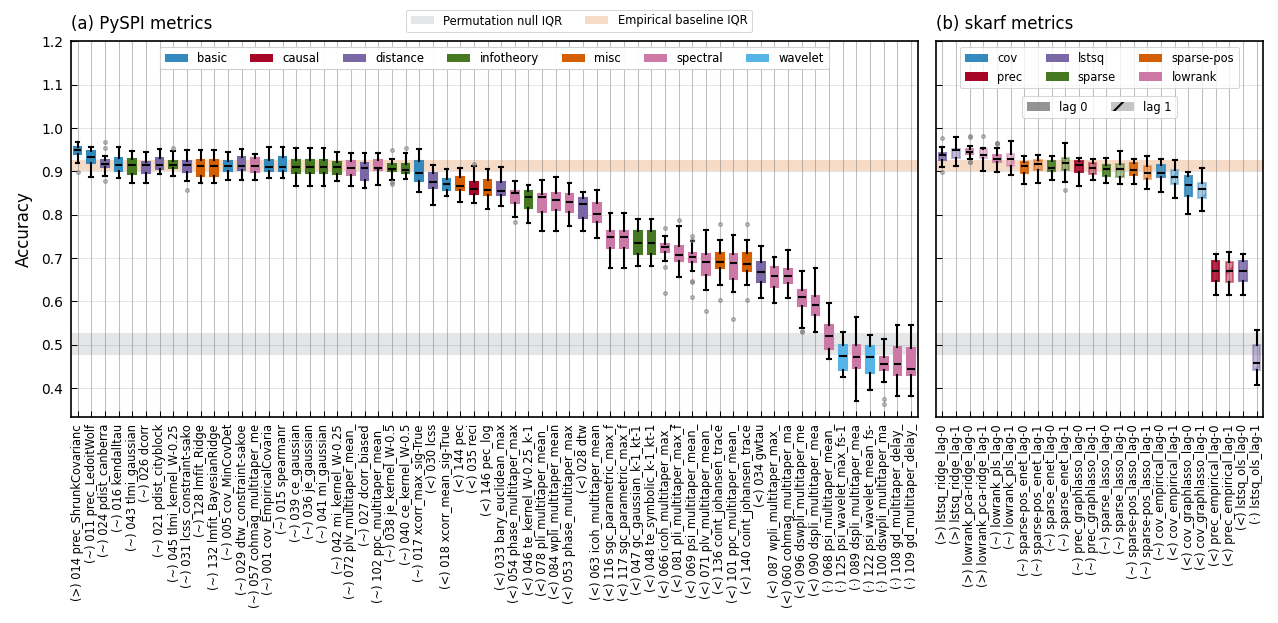

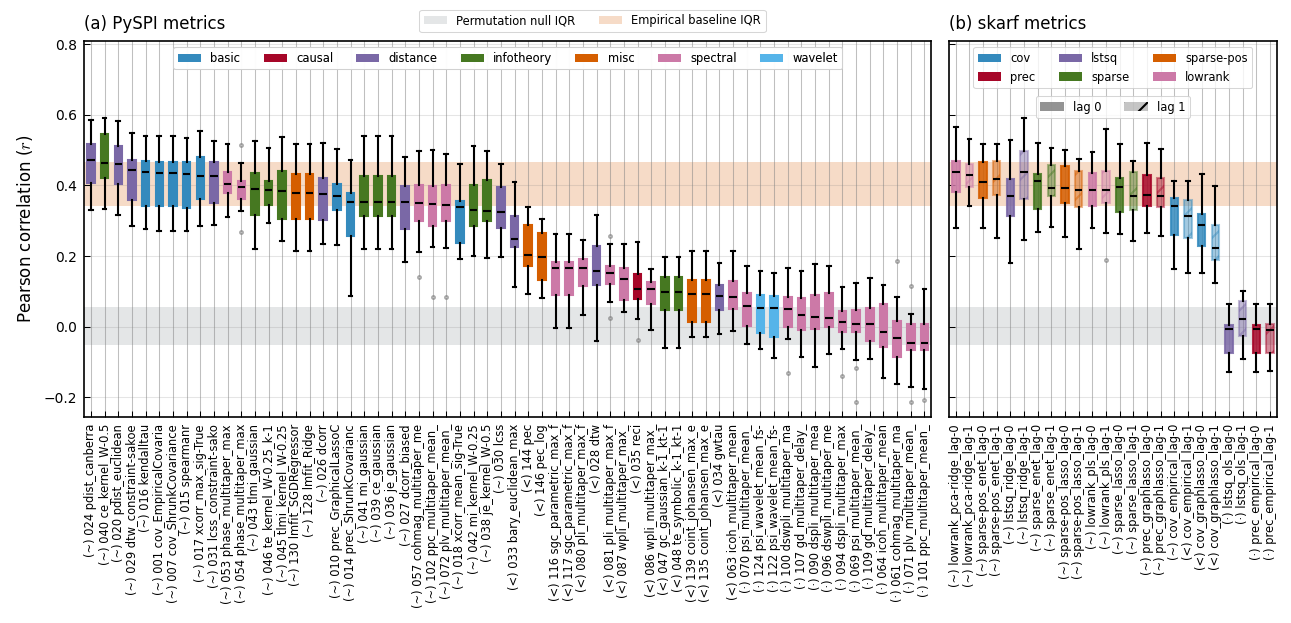

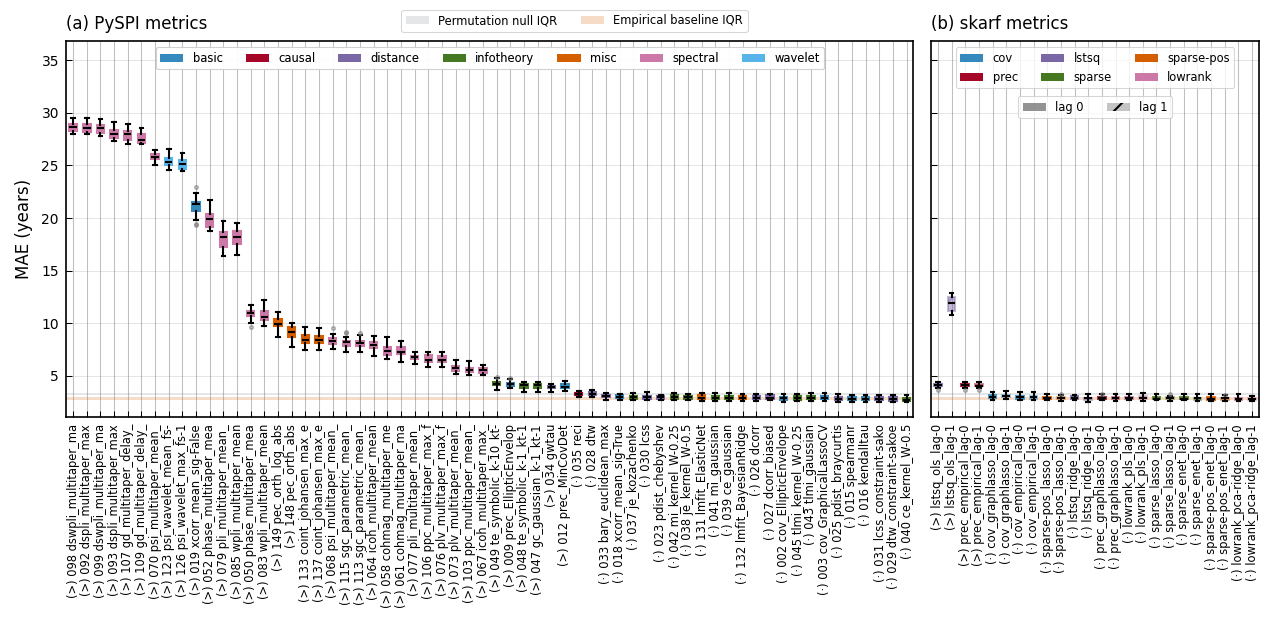

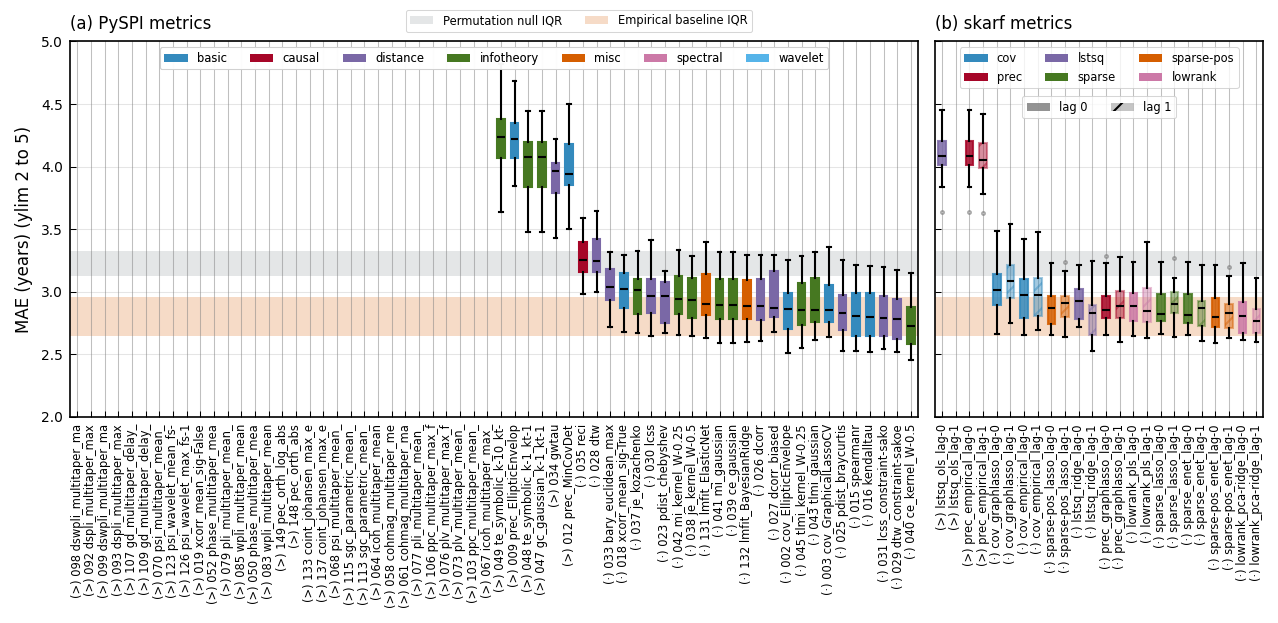

In [32]:
# Sorted by median descending – same as above but boxplots sorted within each subplot
for config_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[config_key]
    pyspi_panel_df = ctx["pyspi_panel_df"].sort_values("median", ascending=False).reset_index(drop=True)
    skarf_panel_df = ctx["skarf_panel_df"]
    skarf_label_map = ctx["skarf_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    # Sort skarf func order by per-function mean median (across lags) descending
    func_medians = skarf_panel_df.groupby("func", observed=True)["median"].mean()
    skarf_func_order = sorted(
        ctx["skarf_func_order"],
        key=lambda f: func_medians.get(f, float("-inf")),
        reverse=True,
    )

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            baseline_q25,
            baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Empirical baseline IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ymin, ymax = ax.get_ylim()
        upper = ymin + 1.2 * (ymax - ymin)
        if config_key == "gender_acc":
            upper = max(upper, 1.2)
        ax.set_ylim(ymin, upper)
    pyspi_handles = [
        mpatches.Patch(facecolor=spi_category_colors[cat], edgecolor="none", label=cat)
        for cat in spi_category_colors
        if cat in pyspi_panel_df["category"].values
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    if config_key == "age_mae_zoom":
        for axis in axes:
            axis.set_ylim(2, 5)

    plt.subplots_adjust(wspace=0.03)
    plt.show()

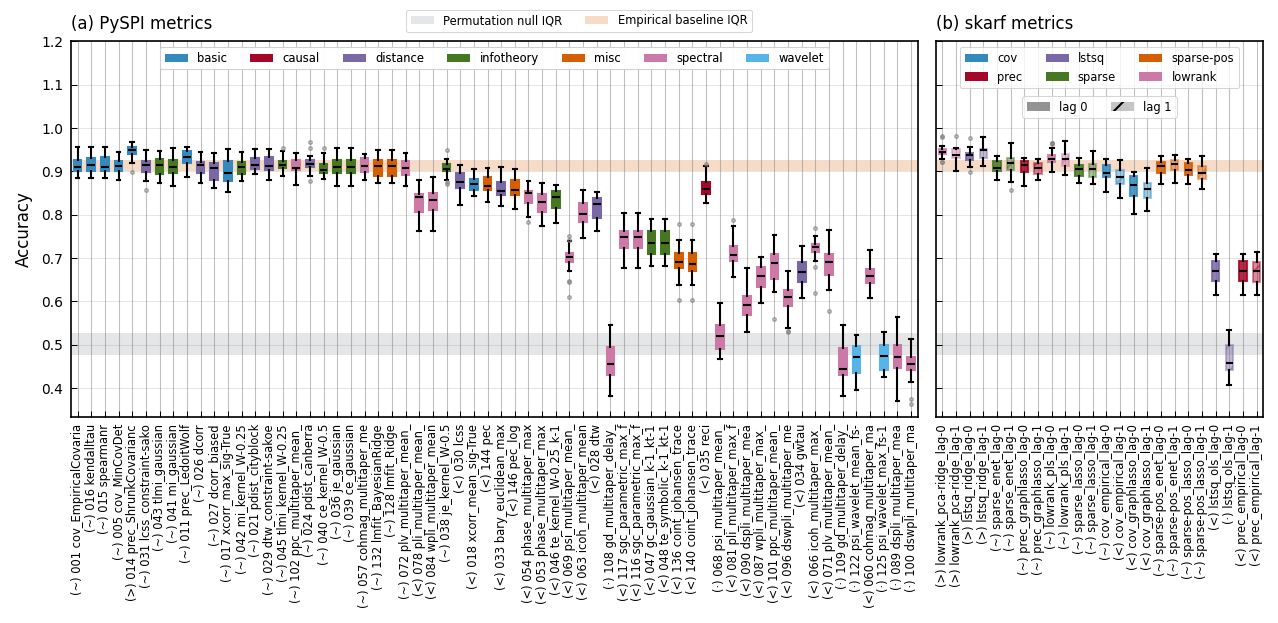

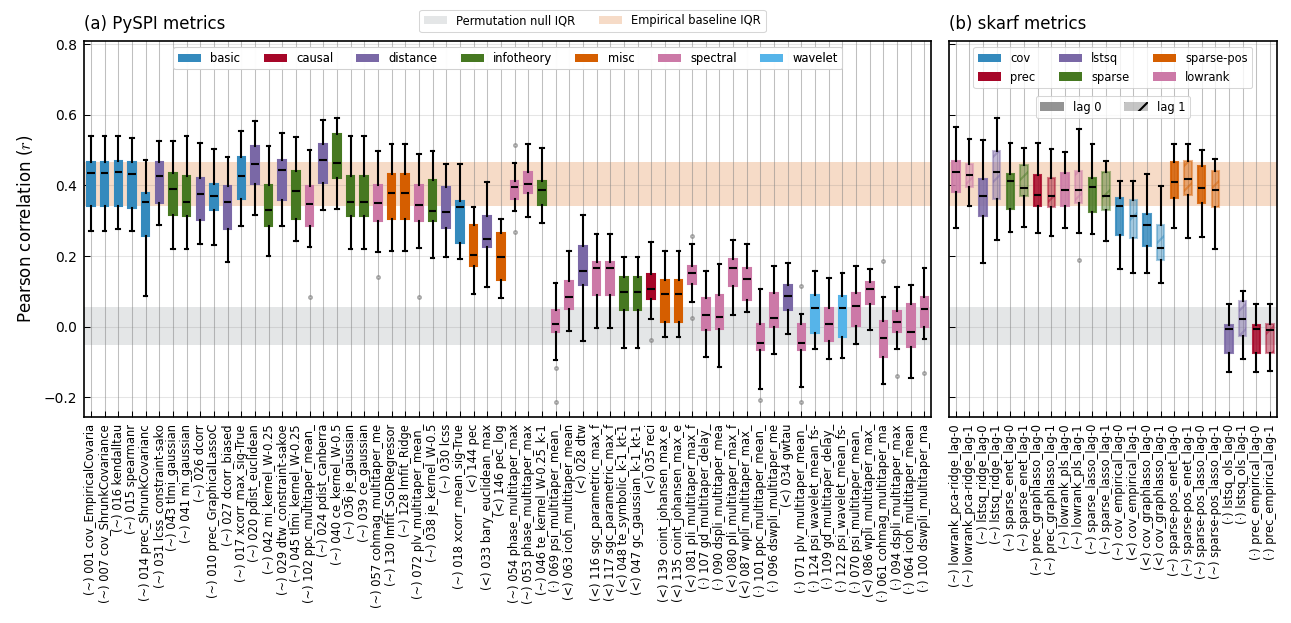

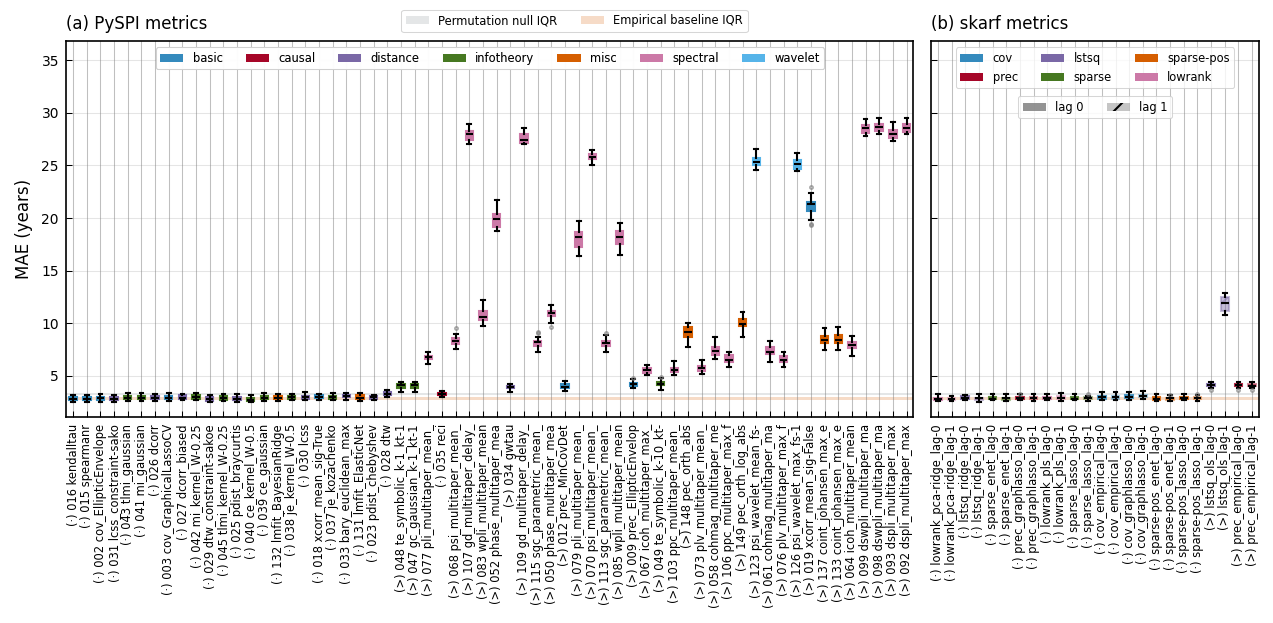

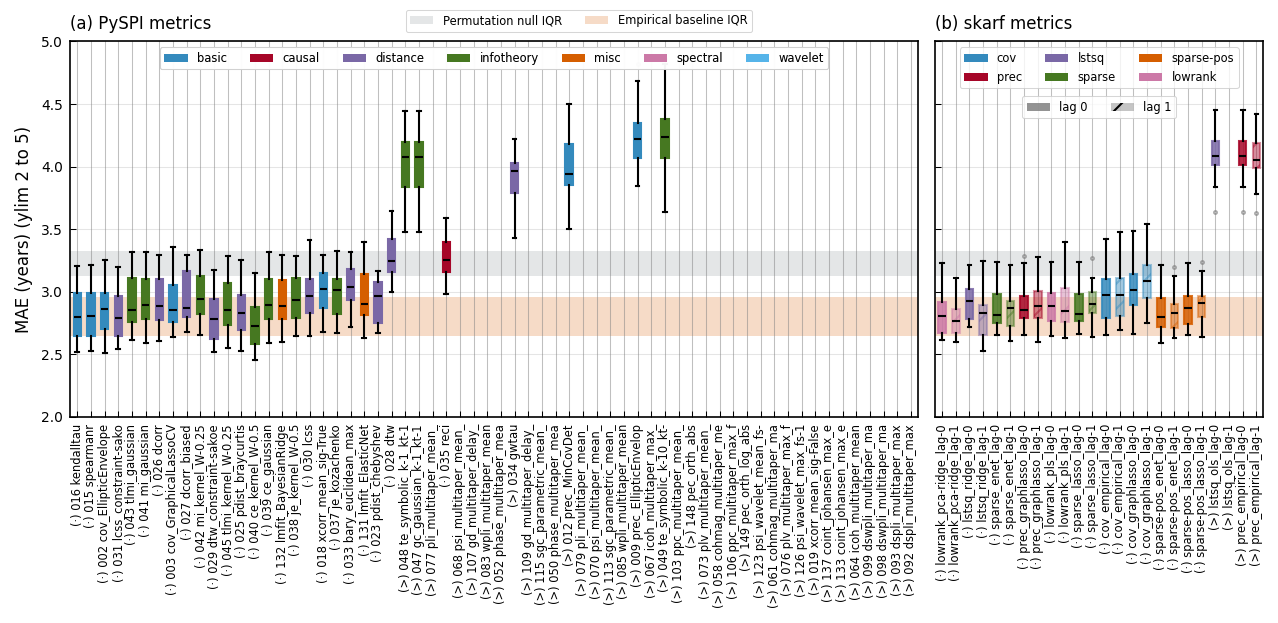

In [33]:
# Rank-ordered plots – boxplots ordered by maxnorm_rank_order from combined benchmark scores
_ranked = pd.read_csv(
    project_root / "results/hcp_1200_benchmark_scores_combined_analysis/combined_benchmark_scores_ranked.csv"
)
# Build per-method lookup: func -> rank (using lag=0 as representative for skarf)
_pyspi_rank = _ranked.query("method == 'pyspi' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()
_skarf_rank = _ranked.query("method == 'skarf' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()

for config_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[config_key]
    pyspi_panel_df = ctx["pyspi_panel_df"].copy()
    skarf_panel_df = ctx["skarf_panel_df"]
    skarf_label_map = ctx["skarf_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    # Sort PySPI by maxnorm_rank_order ascending (lower rank = better = leftmost)
    pyspi_panel_df["_rank"] = pyspi_panel_df["spi"].map(_pyspi_rank)
    pyspi_panel_df = pyspi_panel_df.sort_values("_rank").drop(columns=["_rank"]).reset_index(drop=True)

    # Sort skarf func order by lag-0 maxnorm_rank_order ascending
    skarf_func_order = sorted(
        ctx["skarf_func_order"],
        key=lambda f: _skarf_rank.get(f, float("inf")),
    )

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            baseline_q25,
            baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Empirical baseline IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ymin, ymax = ax.get_ylim()
        upper = ymin + 1.2 * (ymax - ymin)
        if config_key == "gender_acc":
            upper = max(upper, 1.2)
        ax.set_ylim(ymin, upper)
    pyspi_handles = [
        mpatches.Patch(facecolor=spi_category_colors[cat], edgecolor="none", label=cat)
        for cat in spi_category_colors
        if cat in pyspi_panel_df["category"].values
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    if config_key == "age_mae_zoom":
        for axis in axes:
            axis.set_ylim(2, 5)

    plt.subplots_adjust(wspace=0.03)
    plt.show()